In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Merging Datasets

In [67]:
visits = pd.read_csv('/Users/addisonthompson/Desktop/Visit data.csv')

In [68]:
economics = pd.read_csv('/Users/addisonthompson/Desktop/Economic data.csv')

In [69]:
## grouping visits by the year and park 

byYearPark = visits.groupby(by=["Year","Park Name", 'Park Code','State']).sum().reset_index()
byYearPark = byYearPark.drop(columns=['Month'])
byYearPark = byYearPark[byYearPark['Year']<2025]

In [70]:
## merging visits and economics together + getting rid of some extra columns 
visits_economics = pd.merge(byYearPark, economics, left_on=['Year', 'Park Code'], right_on=['Year', 'Code'], how='inner')
visits_economics = visits_economics.drop(columns = ["Name", "Recreation Visits", "Code"])

# COVID Time Series and EDA things

Looking to see if there is any noticible difference in visitation/economics during, before, and after COVID.

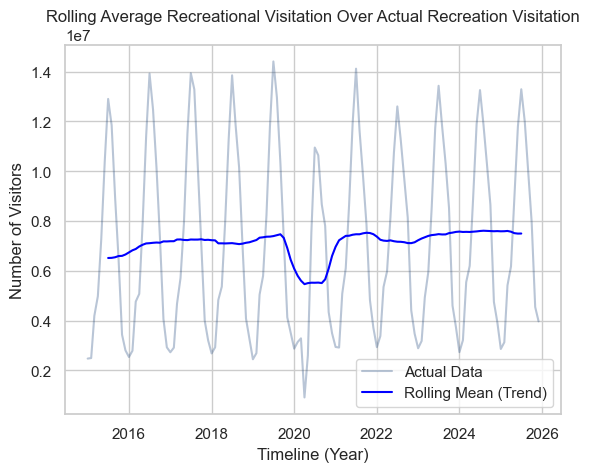

In [71]:
df = visits_df

monthly_data = df.groupby('Date')['Recreation Visitors'].sum().reset_index()

# a rolling avg across the year
monthly_data['Trend'] = monthly_data['Recreation Visitors'].rolling(window=12, center=True).mean()

# plot of how visitation looks with an overlay of what the rolling avg is
plt.plot(monthly_data['Date'], monthly_data['Recreation Visitors'], alpha=0.3, label='Actual Data')
plt.plot(monthly_data['Date'], monthly_data['Trend'], label='Rolling Mean (Trend)', color='blue')
sns.set_style("whitegrid")

plt.title('Rolling Average Recreational Visitation Over Actual Recreation Visitation')
plt.xlabel('Timeline (Year)')
plt.ylabel('Number of Visitors')
plt.legend()



This shows the large dip in park visitation with the clousures from COVID and how noticible it is compared to other years.

/var/folders/_8/csfv5z9j0dx9qgklvj98vll80000gn/T/ipykernel_63268/3283197158.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=seasonal_profile.index, y=seasonal_profile.values, palette='gist_earth')


Text(0, 0.5, 'Recreation Visitors')

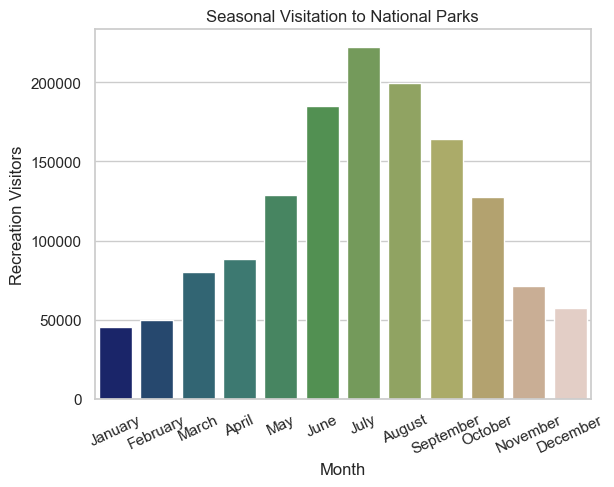

In [76]:
df = visits_df

month_list = {'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
             'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12}

fig, ax = plt.subplots()

# average visitors for each month across all years
seasonal_profile = df.groupby('Month')['Recreation Visitors'].mean().reindex(month_list)

# Plot as a bar chart to show how visitation fluctuates across seasons
sns.barplot(x=seasonal_profile.index, y=seasonal_profile.values, palette='gist_earth')
ax.set_xticks(range(12))
ax.set_xticklabels(labels = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'], rotation=25)
sns.set_style("whitegrid")

plt.title('Seasonal Visitation to National Parks')
plt.ylabel('Recreation Visitors') # x-axis has automatic label

shows that visitation is up during summer months, makes sense with work schedules along with weather

/var/folders/_8/csfv5z9j0dx9qgklvj98vll80000gn/T/ipykernel_63268/1462544608.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_totals, x='Month', y='Recreation Visitors', palette='gist_earth')


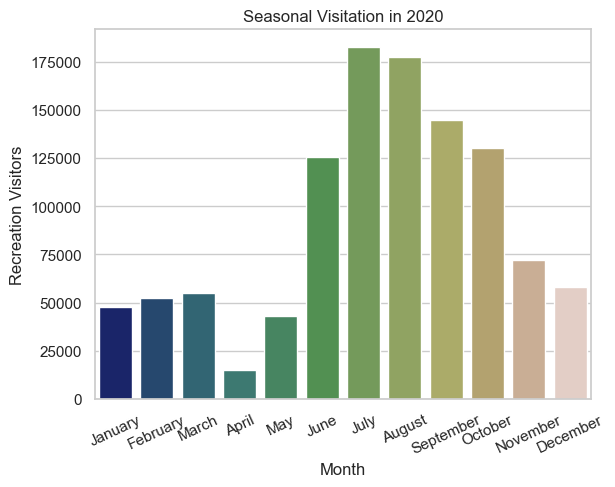

In [77]:
df = visits_df

covid_2020 = df[df['Year'] == 2020] # getting just 2020

fig, ax = plt.subplots()

month_list = {'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
             'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12}

monthly_totals = covid_2020.groupby('Month')['Recreation Visitors'].mean().reindex(month_list).reset_index()

# bar plot of just covid
sns.barplot(data=monthly_totals, x='Month', y='Recreation Visitors', palette='gist_earth')

plt.title('Seasonal Visitation in 2020')

ax.set_xticks(range(12))
ax.set_xticklabels(labels = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'], rotation=25)
sns.set_style("whitegrid")

plt.show()

compared to other seasonal graph before this one, shows how much covid closures affect visitation

Text(0.5, 1.0, '2019-2021 in Recreation Visitation')

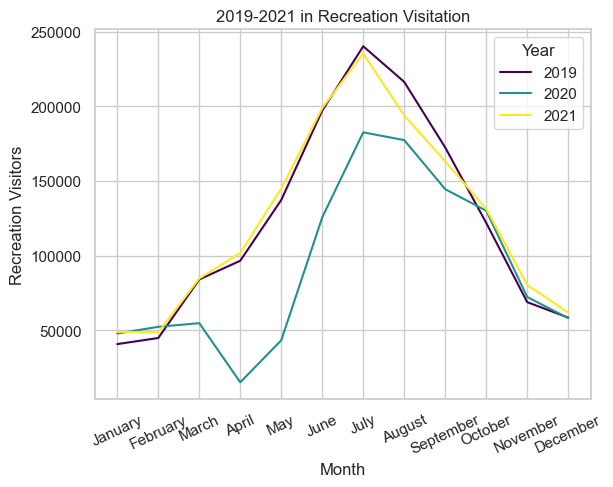

In [74]:
comparison = df[df['Year'].isin([2019, 2020, 2021])] # getting 2019, 2020, and 2021

fig, ax = plt.subplots() # to be able to change axis

sns.lineplot(data=comparison, x='Month', y='Recreation Visitors', hue = 'Year', palette='viridis', errorbar=None) 
# addding errorbar=none to have no confidence interval and just show the number
ax.set_xticks(range(12))
ax.set_xticklabels(labels = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'], rotation=25)

sns.set_style("whitegrid")

plt.title('2019-2021 in Recreation Visitation')

even when park closures where over, the number of visitors in 2020 is much lower due to travel limitations, limited number of visitors allowed into parks, and other factors happening simultaniously